### Best Model Analysis and Exploration

This notebook will be used to explore the results of our best preforming model, eploring the residuals and start the preformance of the residual analysis. We'll need to read in all of the data and eventually join back in the `grid_point_id's` to get a better understanding of the impact of missing data on our model etc.

I think here it also is worth it to explore the fuller model and undertstand where the data is missing where we actually see target data above 0 (e.g. there is a proportion damaged) and what % are missing data.

Overall todo's here:
- read in all the needed data
- join the grid_point_id's back in
- Overall look into where the non-filtered data is missing the ntl data or affected 0 where we have target data showing impact
    - what's the pattern we see here, what can we say about these results and how could this be helped?
- 

Import needed libraries:

In [3]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score, GridSearchCV, RepeatedKFold
from sklearn.ensemble import RandomForestRegressor,ExtraTreesRegressor
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, root_mean_squared_error
import seaborn as sns
import warnings
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler,StandardScaler
import networkx as nx
from itertools import product
import pickle
from sklearn.exceptions import DataConversionWarning
warnings.filterwarnings('ignore', category=DataConversionWarning)
from sklearn.inspection import permutation_importance
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
import matplotlib.cm as cm
plt.rcParams['font.family'] = 'Helvetica'
%matplotlib inline

%matplotlib inline

thesis_cmap_div = mcolors.LinearSegmentedColormap.from_list(
    "thesis_div",
    [
        '#F6511D',  # orange red
        '#EAF2EF',  # off white
        '#097FC7',  # ocean blue
    ]
)

plt.rcParams['font.family'] = 'Helvetica'

BACKGROUND_COLOR = '#EAF2EF'

%load_ext autoreload
%autoreload 2

from helper_functions import *

In [ ]:
def print_feature_importance(model, feature_names, model_name, best_color,other_color):
    importances = model.feature_importances_
    std = np.std([tree.feature_importances_ for tree in model.estimators_], axis=0)
    
    df_imp = pd.DataFrame({
        'importance': importances,
        'std': std,
        'feature': feature_names
    }).sort_values('importance', ascending=True)

    final_df = df_imp[df_imp['importance'] > 0.001] #
    colors = [other_color]*(final_df.shape[0] - 1) + [best_color]
    fig, ax = plt.subplots(figsize=(10, len(feature_names) * 0.25))
    ax.barh(final_df['feature'], final_df['importance'], xerr=final_df['std'], align='center',color=colors)
    ax.set_title(f"Feature importances of in {model_name} Model")
    ax.set_xlabel("Mean decrease in impurity (importance metric)")
    fig.tight_layout()
    plt.show()
    return

def print_feature_importance_pm(model, X_val, y_val, feature_names, other_color, best_color, n_repeats=30):
    r = permutation_importance(model, X_val, y_val, n_repeats=n_repeats, random_state=42)
    
    df_imp = pd.DataFrame({
        'importance': r.importances_mean,
        'std': r.importances_std,
        'feature': feature_names
    }).sort_values('importance', ascending=True)

    final_df = df_imp[df_imp['importance'] > 0.001] #
    colors = [other_color]*(final_df.shape[0] - 1) + [best_color]
    
    fig, ax = plt.subplots(figsize=(10, len(feature_names) * 0.3))
    ax.barh(final_df['feature'], final_df['importance'], xerr=final_df['std'], align='center',color=colors)
    ax.set_title("Feature importances using Permutation Importance")
    ax.set_xlabel("Mean accuracy decrease")
    fig.tight_layout()
    plt.show()

def compute_residuals(model, X_test, y_test):
    '''
    very simply helper function that returns the residuals of our models
    '''
    y_pred = model.predict(X_test)
    return y_test.values.flatten() - y_pred

def plot_residuals(model, X_test, y_test, model_name,figure_name):
    '''
    simple function that computes the residuals of the passed model
    and plots them as a scatter plot with the passed model name (model_name)
    '''
    residuals = compute_residuals(model,X_test, y_test)

    plt.figure(figsize=(10, 4))
    plt.scatter(y_pred, residuals, alpha=0.3)
    plt.axhline(0, color='red', linestyle='--')
    plt.xlabel("Predicted")
    plt.ylabel("Residual")
    plt.title(f"Residual Plot for {model_name} Model")
    plt.tight_layout()
    plt.savefig(f'../figures/{figure_name}')
    plt.show()
    
    return

# we're going to get better distributed boxes
def get_better_dists_for_hists(col,n_bins):
    '''
    This function takes a column and based on the number of boxes
    will return more evenly sized buckets.
    '''
    all_limits = [col.quantile((1/n_bins)*i) for i in range(1,n_bins+1)]

    steps_dict = {}
    size = 1/n_bins
    lower = f'{(0.0 * 100):.2f}%'
    for i in all_limits:
        upper = f'{i*100:.2f}%'
        if i == all_limits[-1]:
            bound_name = f'{lower}+'
        elif i == all_limits[0]:
            bound_name = f'<{upper}'
        else:
            bound_name = f'{lower} - {upper}'
        
        steps_dict[i] = bound_name
        lower = f'{(i) * 100:.2f}%'
    
    return steps_dict

def box_availability_rates(row,hist_box_dict):
    keys_dict = sorted(hist_box_dict.keys())
    for i in keys_dict:
        if row <= i:
            return hist_box_dict[i]

def plot_hisplots_for_subgroups(data,group_col,hist_col,figsize=(15,15),gridspec_row=4,gridspec_col=7,color_list=True,
                                colors=[],group_type='NTL Data Availability',hist_column_type='Residuals',model_name='ExtraTrees',complex=False):
    '''
    This fucntion takes in the passed data and makes a grided plot of all the items passed as distplots to see
    how different categories compare in the residuals (errors).
    --------------------------------------
    data: The dataframe of the model results, etc.
    group_col: the column that has the different categories we want to plot
    hist_col: the column that we want to see the distribution of.
    figsize: the size of the full figure (width, height)
    gridspec_row: the number of rows
    gridspec_col: the number of cols
    color_list: bool - if a list of colors is provided
    colors: the list of colors
    group_type: what is the data that we're grouping by (will be used in a header title, but haven't figured that out).
    '''
    if complex:
        data['ground_truth'] = hist_col
        hist_col = 'ground_truth'
    fig = plt.figure(figsize=figsize)
    gs = gridspec.GridSpec(gridspec_row, gridspec_col)
    for i, group in enumerate(list(data[group_col].unique())):
        if color_list:
            color = colors[i]
        else:
            color = colors
        ax = plt.subplot(gs[i])
        df = data[data[group_col] == group]
        sns.histplot(data=df, x=hist_col,color=color, label=f"Availability Group: {group}", kde=True, stat="density", linewidth=0, bins=50)
        # sns.histplot(data[cn][data.Class == 0], color="red", label="100% Equities", kde=True, stat="density", linewidth=0, bins=50)
        ax.set_xlabel('')
        ax.set_title(f"Availability Group: {group}")
        ax.grid(True)
    
    fig.suptitle(f'Distribution of Model {hist_column_type} by {group_type}', fontsize=16, fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'../figures/residual_gridspec_distribution_{model_name}.png')
    plt.show()

    # # adding an x-axis for the larger grid
    # big_ax = fig.add_subplot(gs[:])
    # big_ax.set_xlabel("Distribution of Model Residuals", labelpad=20, fontsize=14)
    # big_ax.set_facecolor("none")
    # big_ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)
    # for spine in big_ax.spines.values():
    #     spine.set_visible(False)


def plot_geodataframe_choropleth(gdf,column,cmap = "viridis", figsize = None, title = None, vmin = None, 
                                 vmax = None, edge_color = "none", edge_width = 0.1, missing_color = "lightgrey"):
    """
    Plot a GeoDataFrame choropleth using actual polygon geometry,
    colored by a specified column.

    Parameters
    ----------
    gdf: GeoDataFrame with multipolygon/polygon geometry
    column: column name to color by
    cmap: colormap name (default: "viridis")
    figsize: figure size; auto-computed from geometry extent if None
    title: plot title
    vmin/vmax: color scale bounds; auto-detected if None
    edge_color: polygon border color (default: "none" = no borders)
    edge_width: polygon border width (default: 0.1)
    missing_color: color for polygons with NaN values (default: "lightgrey")

    Returns
    -------
    fig, ax: matplotlib figure and axes objects
    """
    # duto figsize from geometry bounds
    if figsize is None:
        bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
        lon_range = bounds[2] - bounds[0]
        lat_range = bounds[3] - bounds[1]
        aspect = lon_range / lat_range if lat_range > 0 else 1.5
        base = 10
        figsize = (base * aspect, base)

    fig, ax = plt.subplots(figsize=figsize)

    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor=edge_color,
        linewidth=edge_width,
        missing_kwds={"color": missing_color, "label": "No data"},
        legend=True,
        legend_kwds={
            "label": column,
            "orientation": "vertical",
            "shrink": 0.7,
            "pad": 0.02,
        },
    )

    ax.set_title(title or f"Choropleth of '{column}'", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Longitude", fontsize=11)
    ax.set_ylabel("Latitude", fontsize=11)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))
    plt.xticks(rotation=45, ha="right")

    ax.set_aspect("equal")  # preserve true geographic shape
    plt.tight_layout()
    return fig, ax

read in our data/models:

In [74]:
#best model
# load model
with open('../models/best_extra_trees_regressor.pkl', 'rb') as file:
    best_ex_model = pickle.load(file)

with open('../models/best_random_forest_regressor.pkl', 'rb') as file:
    best_rf_model = pickle.load(file)

#the columns that we need for the best preforming model
filtered_columns_ex = ['typhoon_year', 'minority_aff', 'prop_NODATA_VALUE_DPmax', 'prop_NODATA_VALUE_pre_event_mean',
                       'mean_recov_dur_avail30', 'median_recov_dur_avail30', 'mean_sd', 'median_sd', 'prob_aff',
                       'aff_cat_four_perc', 'aff_cat_zero_perc', 'total_cells_for_aff', 'mean_DPmax_isna', 'median_DPmax_isna',
                       'mean_pre_event_mean_isna','median_pre_event_mean_isna', 'mean_preevent_avail_isna', 'median_preevent_avail_isna', 'majority_aff',
                       'median_recov_dur_pers_avail30_isna', 'median_available', 'median_DPmax', 'median_pre_event_mean', 'median_impact_dur_avail30',
                       'median_impact_dur_pers_avail30', 'median_preevent_avail', 'affected_perc', 'cert_aff_perc', 'cert_not_aff_perc', 'median_sd_isna']

filtered_columns_rf = columns = ['typhoon_year','prop_NODATA_VALUE_pre_event_mean','mean_impact_dur_avail30','median_impact_dur_avail30','mean_recov_dur_avail30',
                                 'median_recov_dur_avail30','median_sd','aff_cat_four_perc','total_cells_for_aff','prop_not_enough_data_recov_dur_avail30',
                                 'aff_cat_zero_perc','median_recov_dur_pers_avail30_isna','median_available','mean_DPmax','median_pre_event_mean',
                                 'mean_recov_dur_pers_avail30','median_preevent_avail','cert_aff_perc','prob_aff','cert_not_aff_perc','median_sd_isna']

# read in the base filled data for both the rf model and to get the grid points
X_train = pd.read_csv('../data/cleaned_model_data/complex_filling/x_train.csv', index_col=0)
X_test = pd.read_csv('../data/cleaned_model_data/complex_filling/x_test.csv', index_col=0)
y_train = pd.read_csv('../data/cleaned_model_data/complex_filling/y_train.csv', index_col=0)
y_test = pd.read_csv('../data/cleaned_model_data/complex_filling/y_test.csv', index_col=0)

# get the grid_id's for the filtered data
train_mask = X_train.pot_affected_perc >= 0.01
test_mask = X_test.pot_affected_perc >= 0.01

#filter the data for extra trees
X_train_ex = X_train[train_mask]
y_train_ex = y_train[train_mask]
X_test_ex = X_test[test_mask]
y_test_ex = y_test[test_mask]

filtering out only available data for plotting/comparisons:

In [432]:
# read in our data
X_train_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/x_train_2.csv', index_col=0)
X_test_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/x_test_2.csv', index_col=0)
y_train_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/y_train_2.csv', index_col=0)
y_test_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/y_test_2.csv', index_col=0)

# was the best 0.01
train_mask = X_train_2.perc_available_upscaled_new >= 0.1
test_mask = X_test_2.perc_available_upscaled_new >= 0.1

X_train_avail = X_train_2[train_mask]
y_train_avail = y_train_2[train_mask]

X_test_avail = X_test_2[test_mask]
y_test_avail = y_test_2[test_mask]

Looking into feature importance first:

Not fully sure about which one of these is best, but since the model isn't linear then I think the pm version makes most sense here?
Will look into this more for thesis writing.

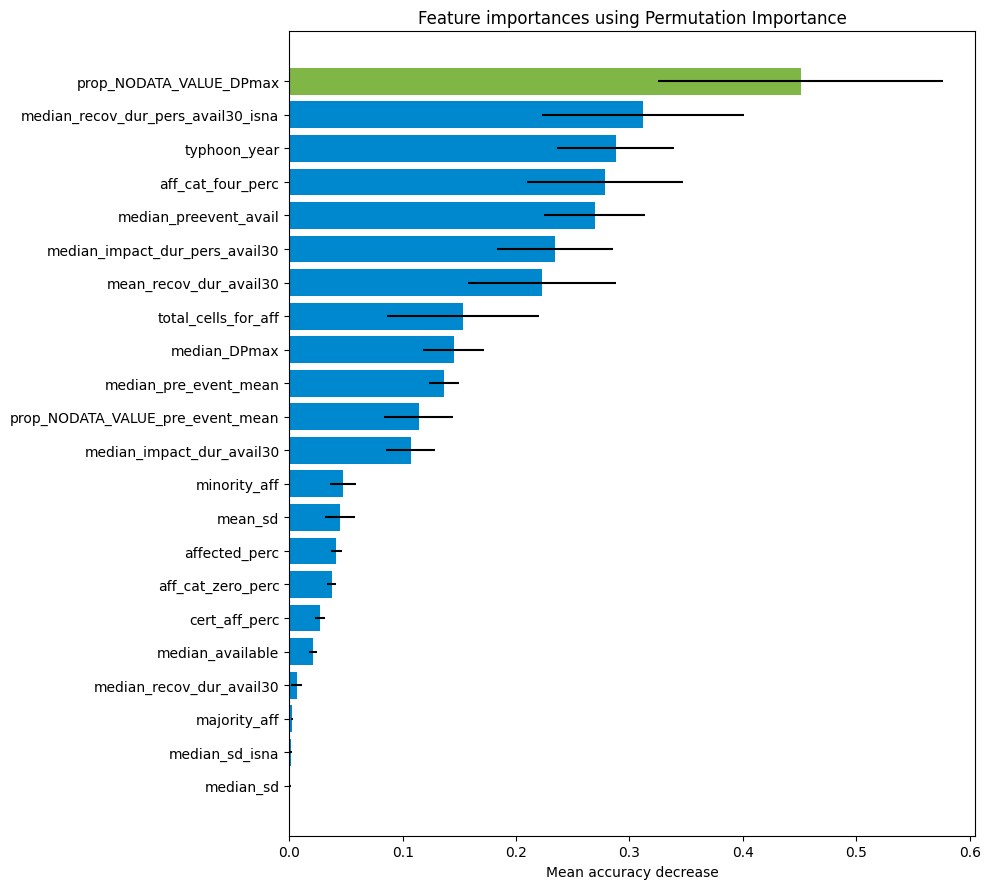

In [ ]:
print_feature_importance_pm(best_ex_model, X_train_ex[filtered_columns_ex], y_train_ex, filtered_columns_ex, '#0088ce','#7fb646',n_repeats=30)

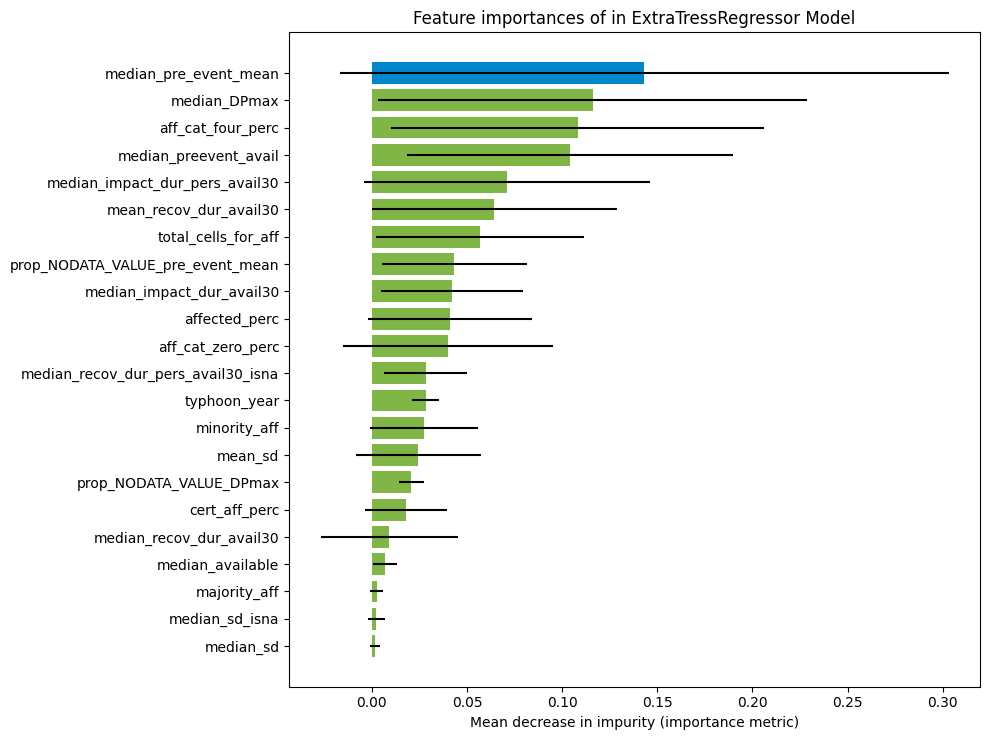

In [56]:
print_feature_importance(best_ex_model,filtered_columns_ex, 'ExtraTressRegressor','#0088ce','#7fb646')

Plotting the residuals for both models to see how they compare systematically:

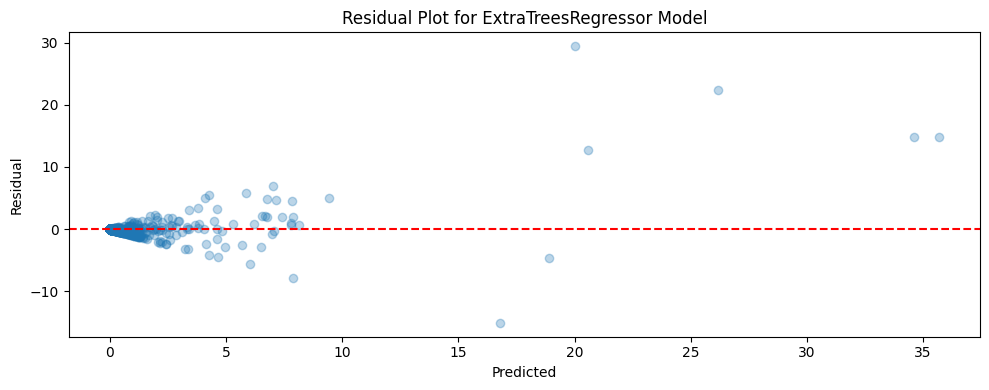

In [71]:
plot_residuals(best_ex_model, X_train_ex[filtered_columns_ex], y_train_ex, "ExtraTreesRegressor")

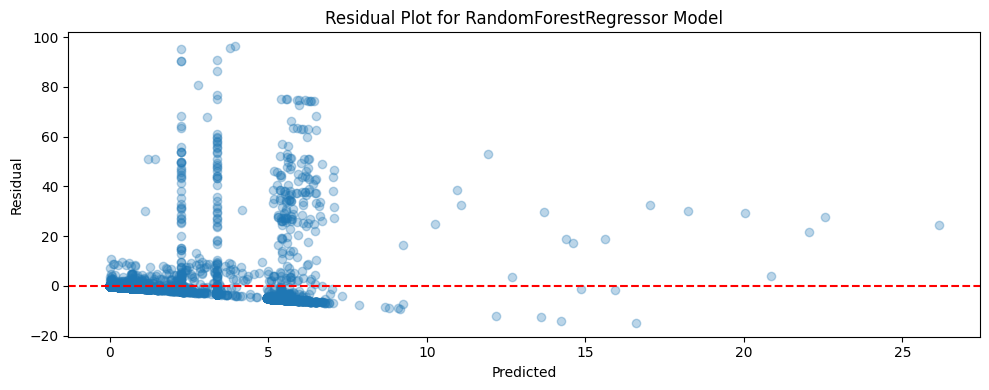

In [75]:
plot_residuals(best_rf_model, X_train[filtered_columns_rf], y_train, "RandomForestRegressor")

### Data Sparcity

Need to look into data Sparcity here and how it relates to the results in both of these models.

The key analysis here is plotting observation count per cell against absolute residual (or some error metric like RMSE per cell). You'd expect a negative relationship — more data, lower error — but the shape and where it breaks down is informative. Some ideas:
- look at how the residuals compare across the different availability groups (like a histogram??)
    -  I actually think this is like individual charts maybe, or we make the groups so that we can then do the hue as the grouping!
- do we see a corrlation between the residuals and the sparcity itself?





/n
- Bin cells by observation count (e.g. <5, 5–20, 20–50, 50+) and compare error distributions across bins for each model
- Flag cells below some threshold and look at where they fall spatially — are sparse cells clustered, and does that spatial pattern correlate with where residuals are highest?
- For the ExtraTrees model in particular, since it was trained only on affected cells, check whether sparse affected cells perform differently than sparse non-affected cells would have — this helps interpret what the filtering gained or lost

Need to see if I have sparcity in the data to begin with and not need to add it to the data frame (can add it by `grid_point_ids`) after. 

In [112]:
# I believe the cell that we want originally is the `available`, maybe need to make a different one vs. just the median one.
X_train_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/x_train_2.csv', index_col=0)
X_test_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/x_test_2.csv', index_col=0)
y_train_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/y_train_2.csv', index_col=0)
y_test_2 = pd.read_csv('../data/cleaned_model_data/complex_filling/y_test_2.csv', index_col=0)

# full data just with the new %
df_with_new_avail = pd.read_csv('../data/target/model_training_data_new_3.csv')

# join the availability data with the full model data
X_train_w_avail = pd.merge(X_train, df_with_new_avail['perc_available_upscaled_new'], left_index=True, right_index=True)
X_test_w_avail = pd.merge(X_test, df_with_new_avail['perc_available_upscaled_new'], left_index=True, right_index=True)
y_train_w_avail = y_train.copy()
y_test_w_avail = y_test.copy()

# join the availability data with the filtered model data
X_train_w_avail_ex = pd.merge(X_train_ex, df_with_new_avail['perc_available_upscaled_new'], left_index=True, right_index=True)
X_test_w_avail_ex = pd.merge(X_test_ex, df_with_new_avail['perc_available_upscaled_new'], left_index=True, right_index=True)
y_train_w_avail_ex = y_train_ex.copy()
y_test_w_avail_ex = y_test_ex.copy()

#### Now we need to look at the residuals based on the data availability data we now have:

In [114]:
# filtered_columns_ex, filtered_columns_rf column groups for getting rediduals

ex_residuals = compute_residuals(best_ex_model, X_test_w_avail_ex[filtered_columns_ex], y_test_w_avail_ex)
full_residuals = compute_residuals(best_rf_model, X_test_w_avail[filtered_columns_rf], y_test_w_avail)
ex_rediduals_non_filt = compute_residuals(best_ex_model, X_test_w_avail[filtered_columns_ex], y_test_w_avail)

**Going to make the residuals their own column in the DataFrame**

In [160]:
# pd.Series(ex_residuals)

X_test_w_avail_ex['ex_model_residuals'] = pd.Series(ex_residuals)
X_test_w_avail['rf_model_residuals'] = pd.Series(full_residuals)
X_test_w_avail['ex_model_residuals'] = pd.Series(ex_rediduals_non_filt)

I think it is worth it to think about the distribution of year data and the fact we're missing 2015-2016

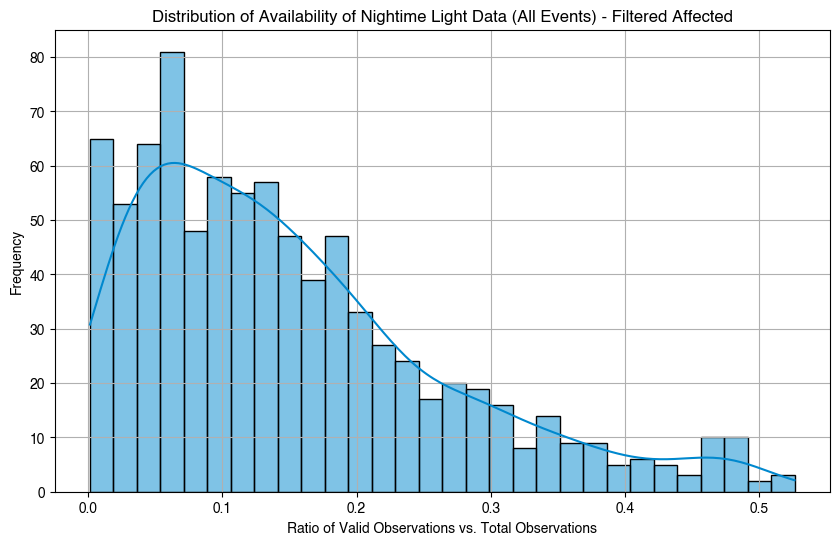

<Figure size 640x480 with 0 Axes>

In [343]:
plt.figure(figsize=(10, 6))
sns.histplot(data=X_test_w_avail_ex, x='perc_available_upscaled_new', bins=30,kde=True,color='#0088ce')
plt.title('Distribution of Availability of Nightime Light Data (All Events) - Filtered Affected')
plt.xlabel('Ratio of Valid Observations vs. Total Observations')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
plt.savefig('../figures/ntl_data_availability_saved_aff.png')

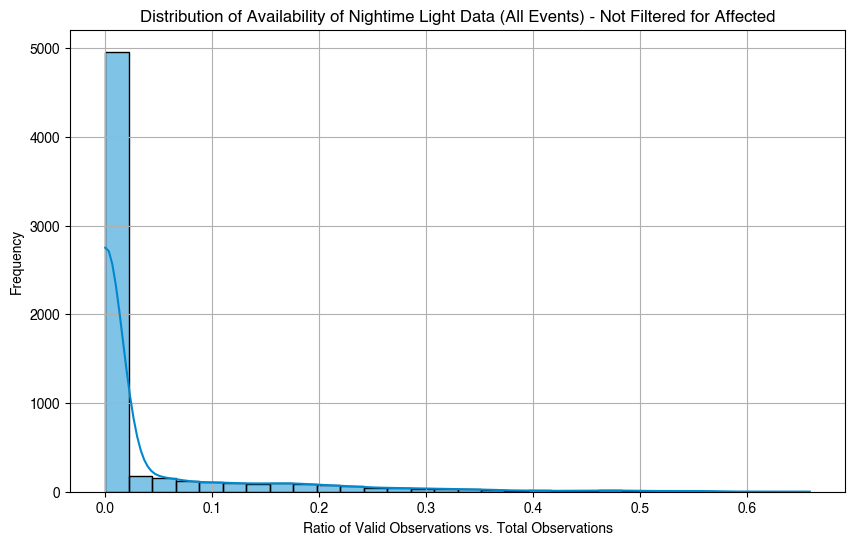

<Figure size 640x480 with 0 Axes>

In [342]:
plt.figure(figsize=(10, 6))
sns.histplot(data=X_test_w_avail, x='perc_available_upscaled_new', bins=30,kde=True,color='#0088ce')
plt.title('Distribution of Availability of Nightime Light Data (All Events) - Not Filtered for Affected')
plt.xlabel('Ratio of Valid Observations vs. Total Observations')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
plt.savefig('../figures/ntl_data_availability_not_filt_aff.png')

In [ ]:
X_test_w_avail_ex[['perc_available_upscaled_new','ex_model_residuals']].corr()

# think through what this means???

,perc_available_upscaled_new,ex_model_residuals
perc_available_upscaled_new,1.000000,0.124336
ex_model_residuals,0.124336,1.000000


In [166]:
X_test_w_avail[['perc_available_upscaled_new','rf_model_residuals']].corr()

,perc_available_upscaled_new,rf_model_residuals
perc_available_upscaled_new,1.00000,0.00171
rf_model_residuals,0.00171,1.00000


In [287]:
boxes = get_better_dists_for_hists(X_test_w_avail_ex.perc_available_upscaled_new,5)
X_test_w_avail_ex['equ_dist_avail_group'] = X_test_w_avail_ex.perc_available_upscaled_new.apply(lambda x: box_availability_rates(x,boxes))

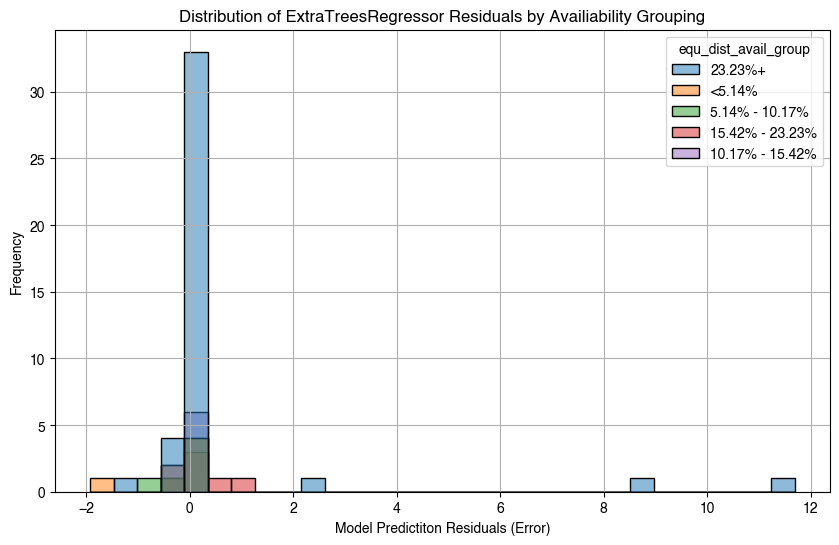

In [285]:
plt.figure(figsize=(10, 6))
sns.histplot(data=X_test_w_avail_ex, x='ex_model_residuals', bins=30,kde=False,color='#0088ce',hue='equ_dist_avail_group')
plt.title('Distribution of ExtraTreesRegressor Residuals by Availiability Grouping')
plt.xlabel('Model Predictiton Residuals (Error)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()
# plt.savefig('../figures/ntl_data_availability_saved_aff.png')

### Show the distibution for the two models test data based on the data availability groups

first with the filtered group:

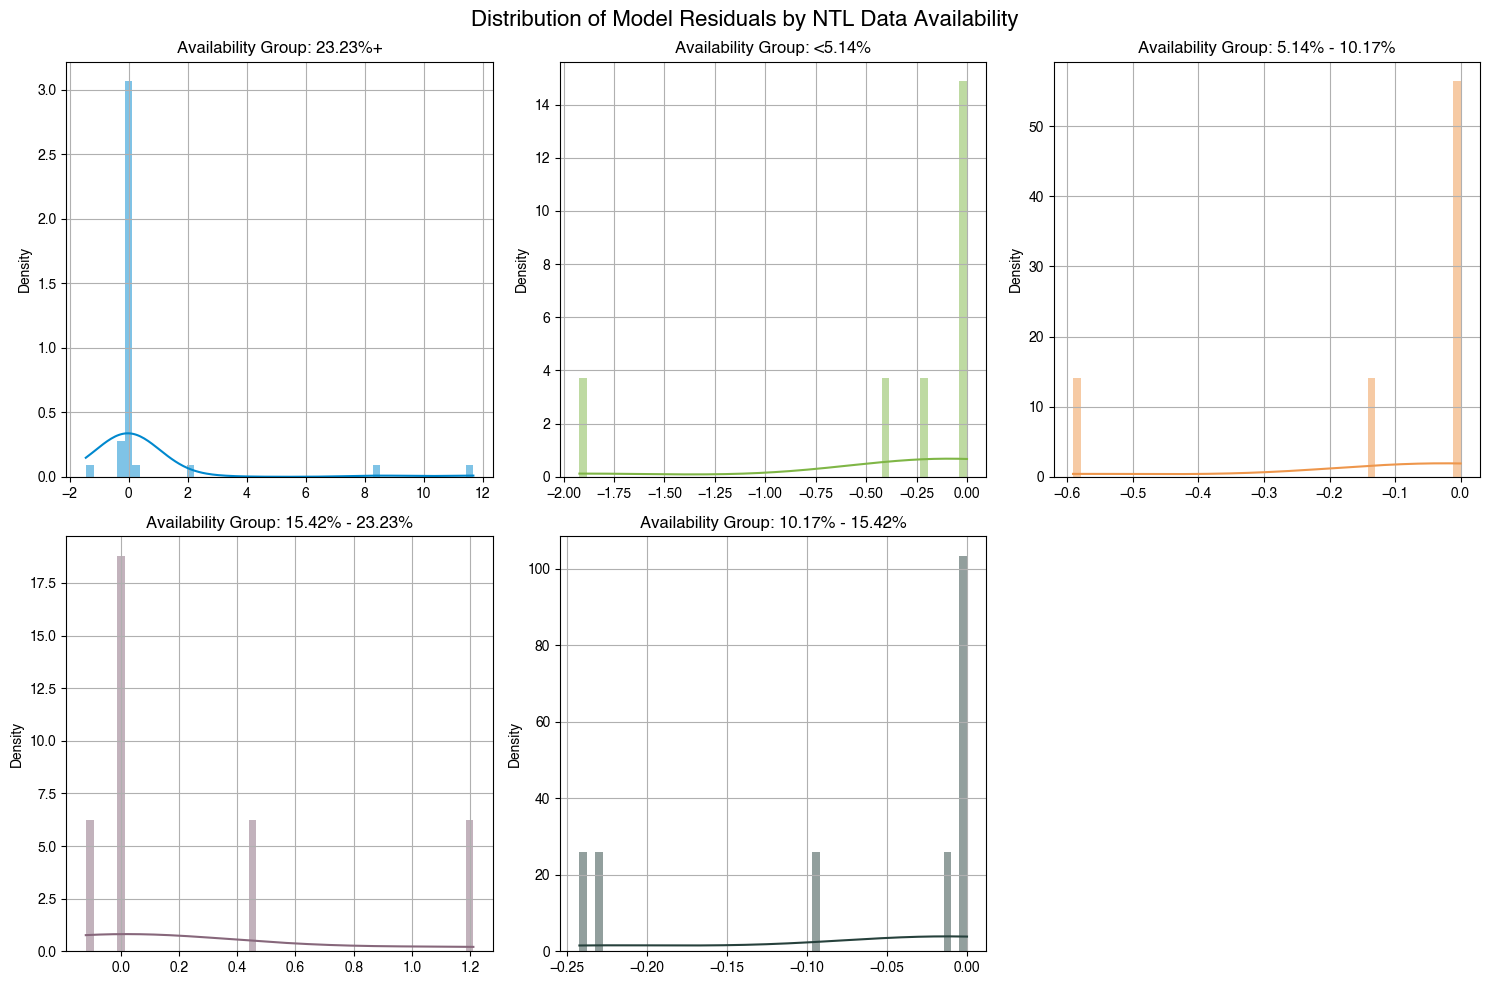

In [355]:
plot_hisplots_for_subgroups(X_test_w_avail_ex,'equ_dist_avail_group','ex_model_residuals',figsize=(15,10),gridspec_row=2,gridspec_col=3,color_list=True,
                            colors=['#0088ce','#7fb646','#ee964b','#87677b','#26413c','#0088ce'])

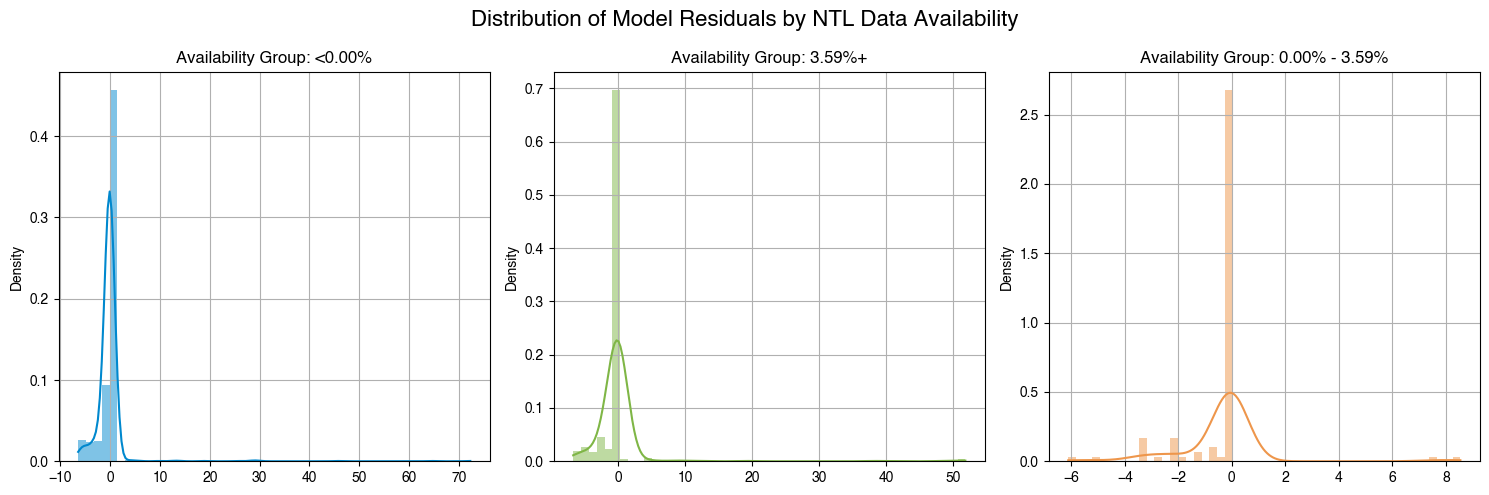

In [356]:
#get the needed hist groups
boxes_rf = get_better_dists_for_hists(X_test_w_avail.perc_available_upscaled_new,5)
X_test_w_avail['equ_dist_avail_group'] = X_test_w_avail.perc_available_upscaled_new.apply(lambda x: box_availability_rates(x,boxes_rf))

# X_test_w_avail['rf_model_residuals'] = pd.Series(full_residuals)
# plot these distibutions
plot_hisplots_for_subgroups(X_test_w_avail,'equ_dist_avail_group','rf_model_residuals',figsize=(15,5),gridspec_row=1,gridspec_col=3,
                            color_list=True,colors=['#0088ce','#7fb646','#ee964b','#87677b','#26413c','#0088ce'],
                            model_name='RandomForest')

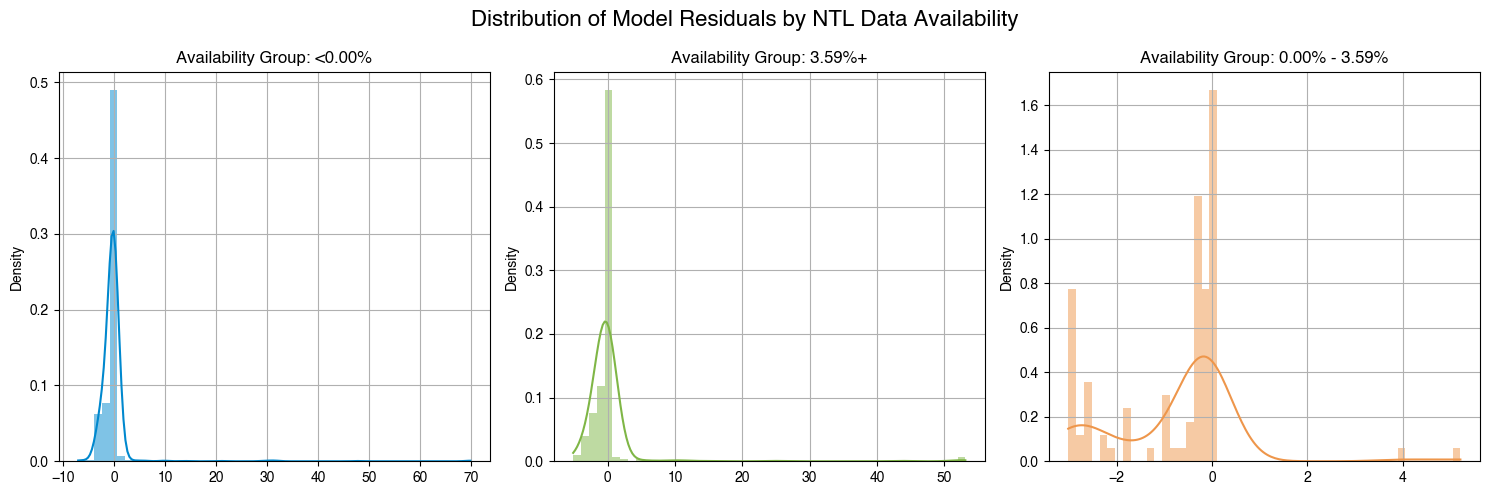

In [357]:
# plot these distibutions
plot_hisplots_for_subgroups(X_test_w_avail,'equ_dist_avail_group','ex_model_residuals',figsize=(15,5),gridspec_row=1,gridspec_col=3,
                            color_list=True,colors=['#0088ce','#7fb646','#ee964b','#87677b','#26413c','#0088ce'],
                            model_name='ExtraTrees_full')

plot_hisplots_for_subgroups(X_test_w_avail,'equ_dist_avail_group',y_test_w_avail,figsize=(15,5),gridspec_row=1,gridspec_col=3,
                            color_list=True,colors=['#0088ce','#7fb646','#ee964b','#87677b','#26413c','#0088ce'],
                            model_name='ExtraTrees_full_target_dist')

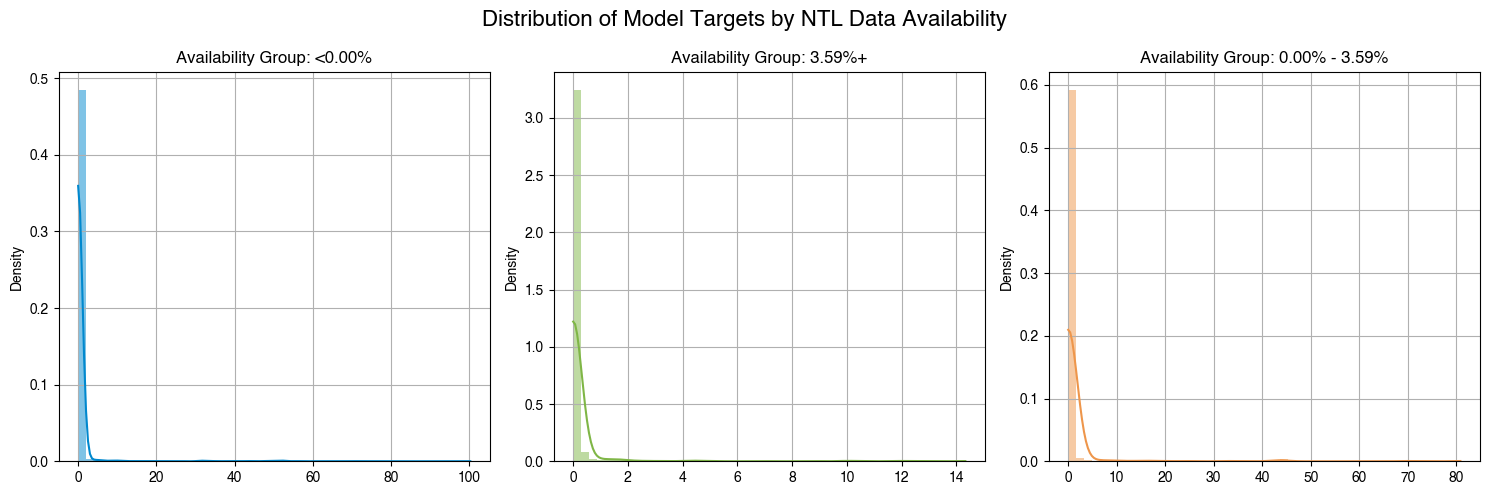

In [358]:
plot_hisplots_for_subgroups(X_test_w_avail,'equ_dist_avail_group',y_test_w_avail,figsize=(15,5),gridspec_row=1,gridspec_col=3,
                            color_list=True,colors=['#0088ce','#7fb646','#ee964b','#87677b','#26413c','#0088ce'],
                            model_name='ExtraTrees_full_target_dist',hist_column_type='Targets',complex=True)

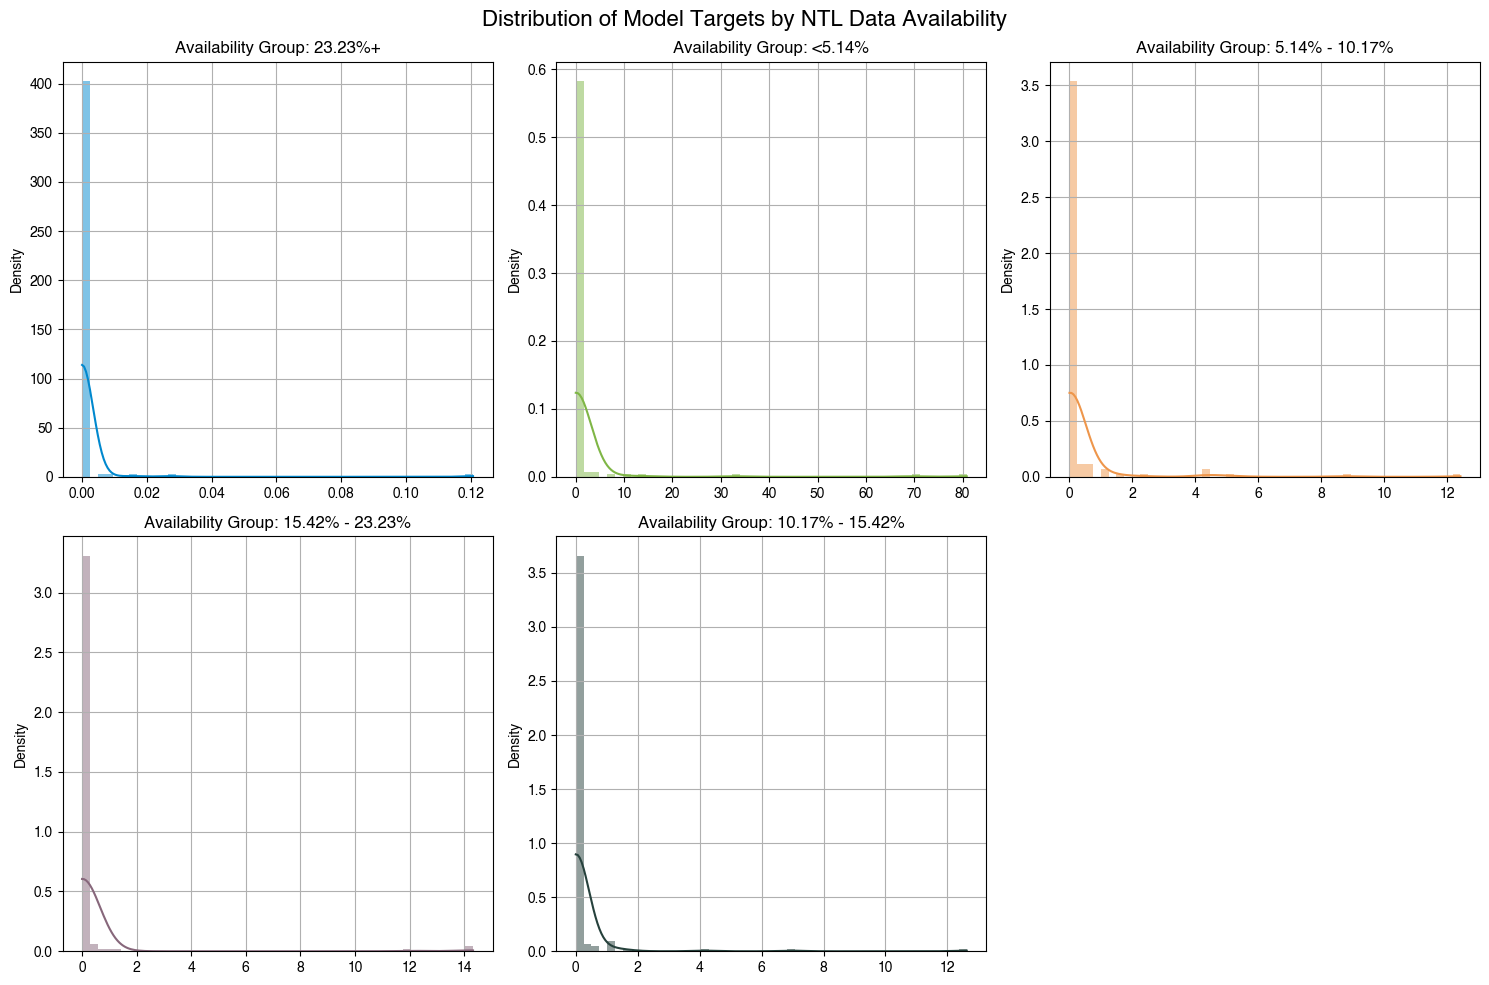

In [359]:
plot_hisplots_for_subgroups(X_test_w_avail_ex,'equ_dist_avail_group',y_test_w_avail_ex,figsize=(15,10),gridspec_row=2,gridspec_col=3,color_list=True,
                            colors=['#0088ce','#7fb646','#ee964b','#87677b','#26413c','#0088ce'],
                            model_name='ExtraTrees_base_target_dist',hist_column_type='Targets',complex=True)

I think it makes sense to have a map that shows the avg % of availability of the grid cell across the events and color code this

Then we'll also do the same for the residuals as well.

this should be the first thing to do tomorrow.

Open question:
- I think it makes sense to make a since to do the singular dataframe here for our results since we have all of these results? or do I only do it on test

In [370]:
grid_point_avail_across_storm_test =  X_test_w_avail.groupby('grid_point_id')['perc_available_upscaled_new'].median()
grid_point_residuals_across_storm_test =  X_test_w_avail.groupby('grid_point_id')['rf_model_residuals'].median()
grid_point_ground_truth_across_storm_test =  X_test_w_avail.groupby('grid_point_id')['ground_truth'].median()

In [369]:
X_test_w_avail

,typhoon_year,grid_point_id,majority_aff,minority_aff,mean_available,median_available,prop_NODATA_VALUE_DPmax,mean_DPmax,median_DPmax,prop_NODATA_VALUE_pre_event_mean,...,median_recov_dur_avail30_isna,mean_recov_dur_pers_avail30_isna,median_recov_dur_pers_avail30_isna,mean_sd_isna,median_sd_isna,perc_available_upscaled_new,rf_model_residuals,ex_model_residuals,equ_dist_avail_group,ground_truth
5217,2013,13288,0.0,0.0,0.00000,0.000000,1.0,0.471941,0.483215,1.0,...,1,1,1,0,0,0.00000,-0.006339,-2.43093,<0.00%,0.000000
6863,2013,18793,0.0,0.0,0.00000,0.000000,1.0,0.471941,0.483215,1.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000
10918,2013,5969,0.0,0.0,0.00000,0.000000,1.0,0.260206,0.381652,1.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000
14860,2013,10079,0.0,0.0,0.00000,0.000000,1.0,-0.209303,-0.094094,0.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000
6440,2013,17498,0.0,0.0,0.00000,0.000000,1.0,0.471941,0.483215,1.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13441,2013,16680,0.0,0.0,0.00000,0.000000,1.0,0.260206,0.381652,1.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000
36918,2018,11070,0.0,1.0,0.18451,0.222222,0.0,0.755938,0.774981,0.0,...,0,0,0,0,0,0.18451,NaN,NaN,3.59%+,0.323606
7294,2013,5967,0.0,0.0,0.00000,0.000000,1.0,0.156878,0.207243,1.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000
24147,2014,16148,0.0,0.0,0.00000,0.000000,1.0,0.269741,0.394246,1.0,...,1,1,1,0,0,0.00000,NaN,NaN,<0.00%,0.000000


In [ ]:
gdf = gpd.read_file('../data/shape_files/clipped_grid_for_analysis.gpkg')

In [ ]:
#rest the column name to make easier to join and reset the index for merging
gdf.rename(columns={'id':'grid_point_id'},inplace=True)
grid_point_avail_across_storm_test = grid_point_avail_across_storm_test.reset_index()
grid_point_residuals_across_storm_test = grid_point_residuals_across_storm_test.reset_index()
grid_point_ground_truth_across_storm_test = grid_point_ground_truth_across_storm_test.reset_index()

#join the geodata to these median values for plotting
grid_point_avail_across_storm_test_gdf = gdf.merge(grid_point_avail_across_storm_test, on='grid_point_id', how='right')
grid_point_residuals_across_storm_test_gdf = gdf.merge(grid_point_residuals_across_storm_test, on='grid_point_id', how='right')
grid_point_ground_truth_across_storm_test_gdf = gdf.merge(grid_point_ground_truth_across_storm_test, on='grid_point_id', how='right')

In [405]:
grid_point_residuals_across_storm_test_gdf

,grid_point_id,Longitude,Latitude,Centroid,geometry,rf_model_residuals
0,4475,116.9,7.9,116.9E_7.9N,"MULTIPOLYGON (((116.95 7.91394, 116.94995 7.91...",-0.046273
1,4639,117.0,8.2,117.0E_8.2N,"MULTIPOLYGON (((117.01008 8.18429, 117.01012 8...",NaN
2,4640,117.0,8.1,117.0E_8.1N,"MULTIPOLYGON (((117.05 8.05, 116.99617 8.05, 1...",-0.006092
3,4641,117.0,8.0,117.0E_8.0N,"MULTIPOLYGON (((116.9766 8.05, 116.97665 8.049...",NaN
4,4642,117.0,7.9,117.0E_7.9N,"MULTIPOLYGON (((117.05 7.95, 117.05 7.85, 116....",NaN
...,...,...,...,...,...,...
3151,20677,126.6,7.6,126.6E_7.6N,"MULTIPOLYGON (((126.56128 7.65, 126.56128 7.64...",-0.029047
3152,20678,126.6,7.5,126.6E_7.5N,"MULTIPOLYGON (((126.5885 7.55, 126.58851 7.549...",NaN
3153,20679,126.6,7.4,126.6E_7.4N,"MULTIPOLYGON (((126.60003 7.45, 126.59995 7.44...",NaN
3154,20680,126.6,7.3,126.6E_7.3N,"MULTIPOLYGON (((126.56148 7.35, 126.56156 7.34...",-0.034668


In [3]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


def plot_geodataframe_choropleth(
    gdf: gpd.GeoDataFrame,
    column: str,
    cmap: str = "viridis",
    figsize: tuple = None,
    title: str = None,
    vmin: float = None,
    vmax: float = None,
    edge_color: str = "none",
    edge_width: float = 0.1,
    missing_color: str = "lightgrey",
):
    """
    Plot a GeoDataFrame choropleth using actual polygon geometry,
    colored by a specified column.

    Parameters
    ----------
    gdf           : GeoDataFrame with MultiPolygon/Polygon geometry
    column        : Column name to color by
    cmap          : Colormap name (default: "viridis")
    figsize       : Figure size; auto-computed from geometry extent if None
    title         : Plot title
    vmin/vmax     : Color scale bounds; auto-detected if None
    edge_color    : Polygon border color (default: "none" = no borders)
    edge_width    : Polygon border width (default: 0.1)
    missing_color : Color for polygons with NaN values (default: "lightgrey")

    Returns
    -------
    fig, ax : Matplotlib Figure and Axes objects
    """
    # --- Auto figsize from geometry bounds ---
    if figsize is None:
        bounds = gdf.total_bounds  # [minx, miny, maxx, maxy]
        lon_range = bounds[2] - bounds[0]
        lat_range = bounds[3] - bounds[1]
        aspect = lon_range / lat_range if lat_range > 0 else 1.5
        base = 10
        figsize = (base * aspect, base)

    fig, ax = plt.subplots(figsize=figsize)

    gdf.plot(
        column=column,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        edgecolor=edge_color,
        linewidth=edge_width,
        missing_kwds={"color": missing_color, "label": "No data"},
        legend=True,
        legend_kwds={
            "label": column,
            "orientation": "vertical",
            "shrink": 0.7,
            "pad": 0.02,
        },
    )

    ax.set_title(title or f"Choropleth of '{column}'", fontsize=14, fontweight="bold", pad=12)
    ax.set_xlabel("Longitude", fontsize=11)
    ax.set_ylabel("Latitude", fontsize=11)

    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))
    plt.xticks(rotation=45, ha="right")

    ax.set_aspect("equal")  # preserve true geographic shape
    plt.tight_layout()
    return fig, ax

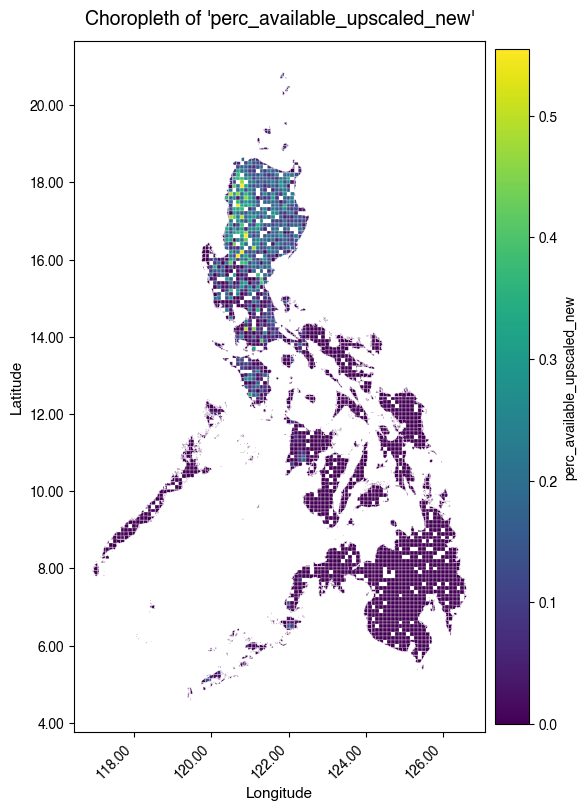

In [395]:
fig, ax = plot_geodataframe_choropleth(
    grid_point_avail_across_storm_test_gdf,
    column="perc_available_upscaled_new",
    cmap="viridis",
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
)
plt.show()

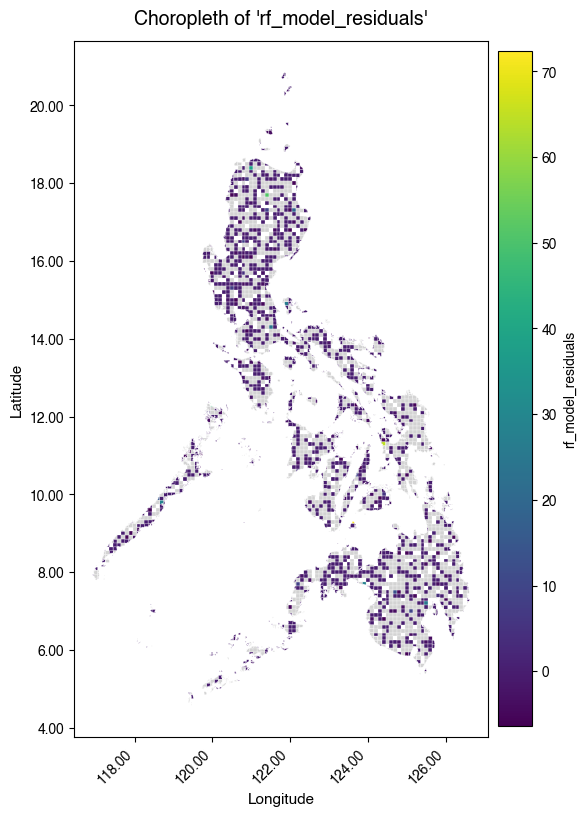

In [ ]:
fig, ax = plot_geodataframe_choropleth(
    grid_point_residuals_across_storm_test_gdf,
    column="rf_model_residuals",
    cmap="viridis",
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
)
plt.show()

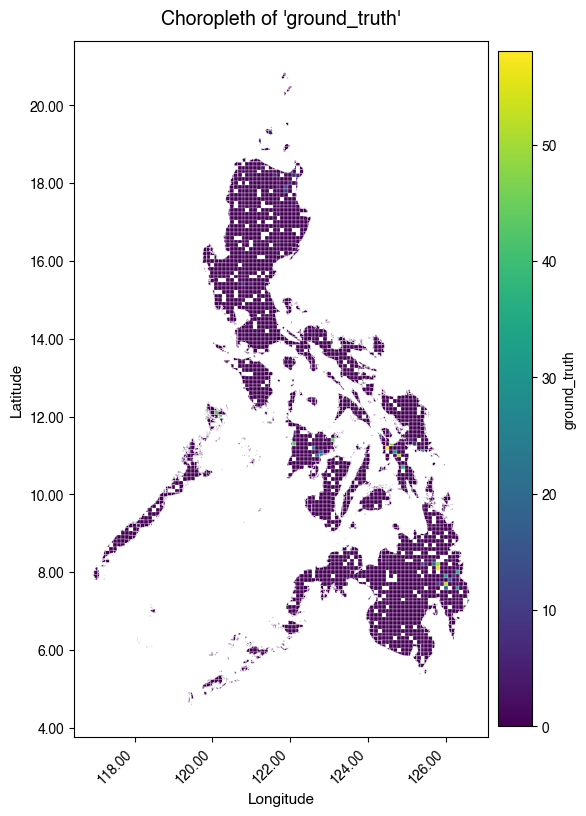

In [442]:
fig, ax = plot_geodataframe_choropleth(
    grid_point_ground_truth_across_storm_test_gdf,
    column="ground_truth",
    cmap="viridis",
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
)
plt.show()

In [ ]:
# look at the ground cover type to see how this relates the the availability


In [4]:
import geopandas as gpd
import matplotlib.pyplot as plt
from typing import List


def plot_choropleth_grid(
    gdfs: List[gpd.GeoDataFrame],
    columns: List[str],
    titles: List[str] = None,
    cmaps: List[str] = None,
    figsize: tuple = None,
    suptitle: str = None,
    vmin: float = None,
    vmax: float = None,
    edge_color: str = "none",
    edge_width: float = 0.1,
    missing_color: str = "lightgrey",
    shared_scale: bool = False,
):
    """
    Plot exactly three choropleth maps side-by-side in a 1x3 grid.

    Parameters
    ----------
    gdfs          : list of GeoDataFrame with MultiPolygon/Polygon geometry
    columns      : List of exactly 3 column names to plot
    titles       : List of 3 titles (defaults to column names)
    cmaps        : List of 3 colormap names (defaults to "viridis" for all)
    figsize      : Overall figure size; auto-computed if None
    suptitle     : Optional super-title across all three plots
    vmin/vmax    : Global color scale bounds (applied to all if shared_scale=True)
    edge_color   : Polygon border color (default: "none")
    edge_width   : Polygon border width (default: 0.1)
    missing_color: Color for NaN polygons (default: "lightgrey")
    shared_scale : If True, all plots share the same vmin/vmax derived from
                   the range across all three columns (overrides vmin/vmax)

    Returns
    -------
    fig, axes : Matplotlib Figure and array of 3 Axes
    """

    len_gdfs = len(gdfs)

    if len(columns) != len_gdfs:
        raise ValueError(f"Expected exactly {len_gdfs} columns, got {len(columns)}")

    titles = titles or columns
    cmaps  = cmaps  or ["viridis"] * 3

    if len(titles) != len_gdfs or len(cmaps) != len_gdfs:
        raise ValueError(f"titles and cmaps must each have exactly {len_gdfs} elements")

    # --- Shared color scale across all three columns ---
    if shared_scale:
        all_vals = gdfs[0][columns].values
        vmin = float(np.nanmin(all_vals))
        vmax = float(np.nanmax(all_vals))

    # --- Auto figsize ---
    if figsize is None:
        bounds    = gdfs[0].total_bounds          # [minx, miny, maxx, maxy]
        lon_range = bounds[2] - bounds[0]
        lat_range = bounds[3] - bounds[1]
        aspect    = lon_range / lat_range if lat_range > 0 else 1.5
        panel_w   = 6 * aspect
        figsize   = (panel_w * len_gdfs, 6)

    fig, axes = plt.subplots(1, len_gdfs, figsize=figsize)

    for gdf, ax, col, title, cmap in zip(gdfs, axes, columns, titles, cmaps):
        gdf.plot(
            column=col,
            ax=ax,
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            edgecolor=edge_color,
            linewidth=edge_width,
            missing_kwds={"color": missing_color, "label": "No data"},
            legend=True,
            legend_kwds={
                "label": col,
                "orientation": "vertical",
                "shrink": 0.7,
                "pad": 0.02,
            },
        )
        ax.set_title(title, fontsize=13, fontweight="bold", pad=10)
        ax.set_xlabel("Longitude", fontsize=10)
        ax.set_ylabel("Latitude", fontsize=10)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.2f}"))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f"{y:.2f}"))
        ax.tick_params(axis="x", rotation=45)
        ax.set_aspect("equal")

    if suptitle:
        fig.suptitle(suptitle, fontsize=16, fontweight="bold", y=0.9)

    plt.tight_layout()
    return fig, axes

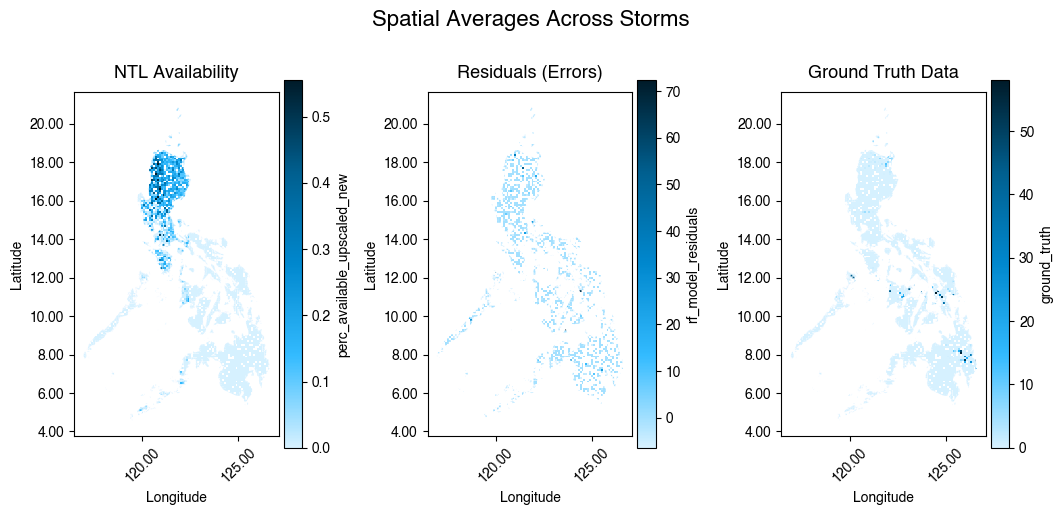

In [429]:
cmap1 = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#0088ce', '#7fb646', '#ee964b', '#87677b', '#26413c']
)

same_scale_color_map = mcolors.LinearSegmentedColormap.from_list(
    "my_cmap",
    ['#D6F1FF', '#33BBFF', '#0088ce', '#005F8F', '#001B29']
)

fig, axes = plot_choropleth_grid(
    [grid_point_avail_across_storm_test_gdf,grid_point_residuals_across_storm_test_gdf,grid_point_ground_truth_across_storm_test_gdf],
    columns=['perc_available_upscaled_new','rf_model_residuals','ground_truth'],
    titles=["NTL Availability", "Residuals (Errors)", "Ground Truth Data"],
    cmaps=[same_scale_color_map, same_scale_color_map, same_scale_color_map],
    suptitle="Spatial Averages Across Storms",
    missing_color='white',
    shared_scale=False,   # all panels use the same min/max
)
plt.show()

### look at the ground cover type to see how this relates the the availability

### need to also plot which cells are kept after the filtering out in the best preforming models
-- I think a count for how many times they show up in the data, since we know that there is one per storm and w have like 12 storms, so can do something like that and the ones that are fully out will be white or grey... maybe the first thing to do here


In [433]:
#using these to count the avaibility of each of the gridcells and then will plot 
#similarly to before

X_train_avail = X_train_2[train_mask]
y_train_avail = y_train_2[train_mask]

X_test_avail = X_test_2[test_mask]
y_test_avail = y_test_2[test_mask]

In [ ]:
X_train_availability_cell_counts = X_train_avail.groupby('grid_point_id').count()['typhoon_year'].reset_index().rename(columns={'typhoon_year':'count'})
X_test_availability_cell_counts = X_test_avail.groupby('grid_point_id').count()['typhoon_year'].reset_index().rename(columns={'typhoon_year':'count'})

In [447]:
X_train_availability_cell_counts_gdf = gdf.merge(X_train_availability_cell_counts, on='grid_point_id', how='left')
X_test_availability_cell_counts_gdf = gdf.merge(X_test_availability_cell_counts, on='grid_point_id', how='left')

In [448]:
X_train_availability_cell_counts_gdf.columns

Index(['grid_point_id', 'Longitude', 'Latitude', 'Centroid', 'geometry',
       'count'],
      dtype='str')

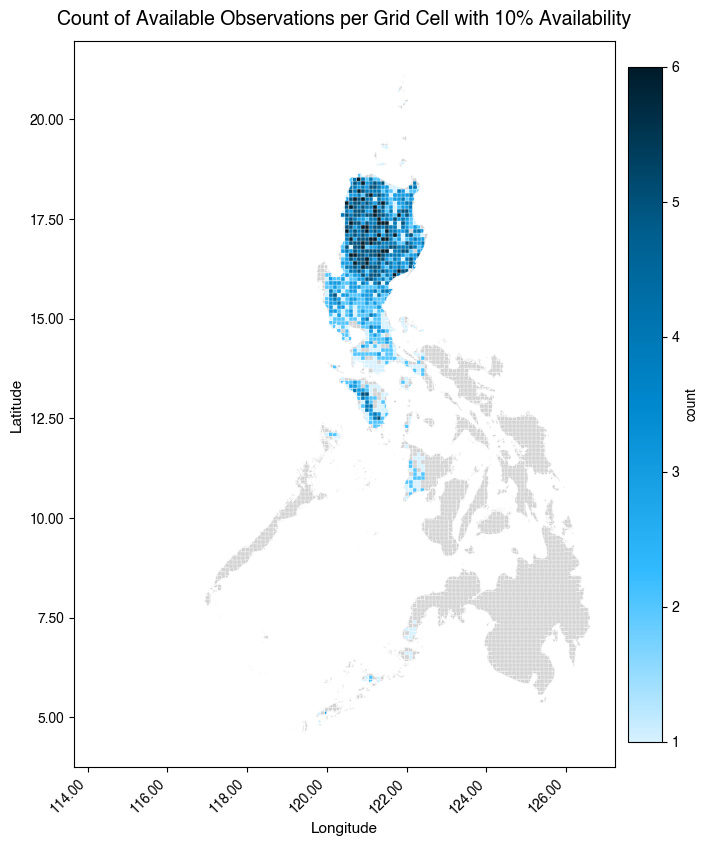

In [458]:
fig, ax = plot_geodataframe_choropleth(
    X_train_availability_cell_counts_gdf,
    column="count",
    cmap=same_scale_color_map,
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
    title="Count of Available Observations per Grid Cell with 10% Availability"
)
plt.show()

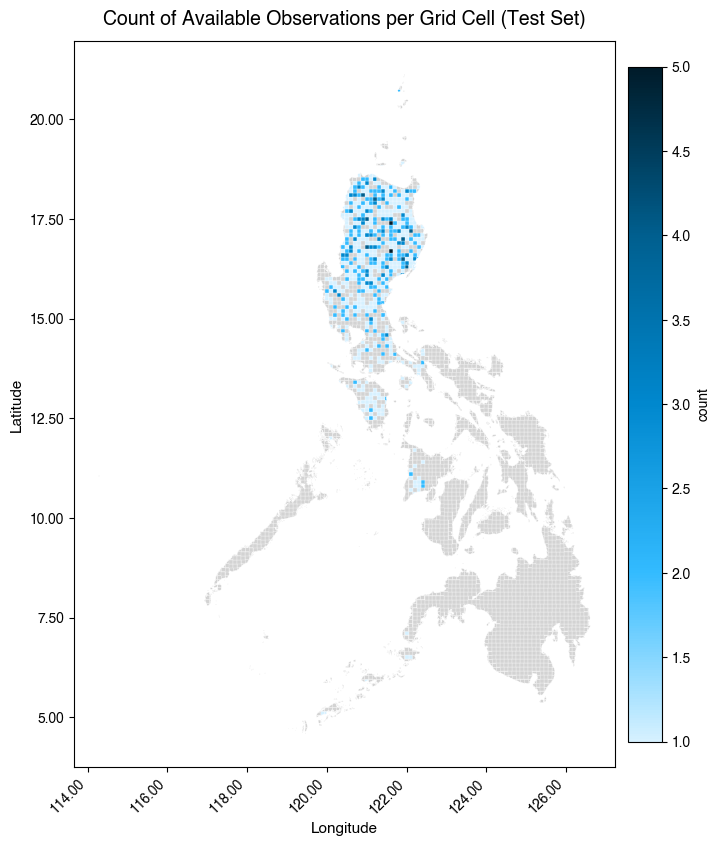

In [453]:
fig, ax = plot_geodataframe_choropleth(
    X_test_availability_cell_counts_gdf,
    column="count",
    cmap=same_scale_color_map,
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
    title="Count of Available Observations per Grid Cell (Test Set)"
)
plt.show()

In [455]:
X_train_total_cell_counts = X_train_2.groupby('grid_point_id').count()['typhoon_year'].reset_index().rename(columns={'typhoon_year':'count'})
X_test_total_cell_counts = X_test_2.groupby('grid_point_id').count()['typhoon_year'].reset_index().rename(columns={'typhoon_year':'count'})

X_train_total_cell_counts_gdf = gdf.merge(X_train_total_cell_counts, on='grid_point_id', how='left')
X_test_total_cell_counts_gdf = gdf.merge(X_test_total_cell_counts, on='grid_point_id', how='left')

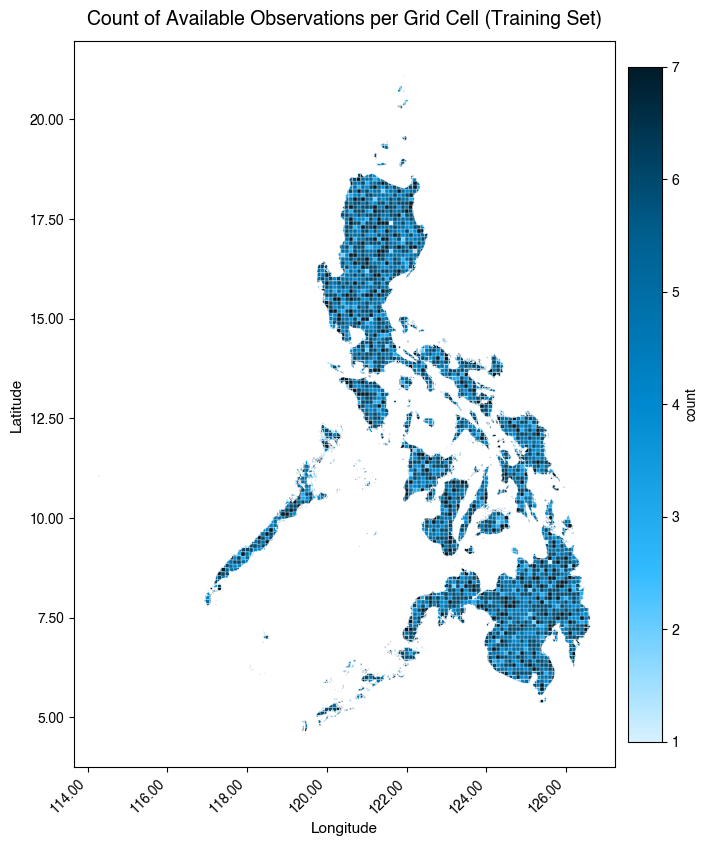

In [ ]:
fig, ax = plot_geodataframe_choropleth(
    X_train_total_cell_counts_gdf,
    column="count",
    cmap=same_scale_color_map,
    edge_color="white",   # thin white borders to distinguish polygons
    edge_width=0.2,
    title="Count of Available Observations per Grid Cell Total"
)
plt.show()

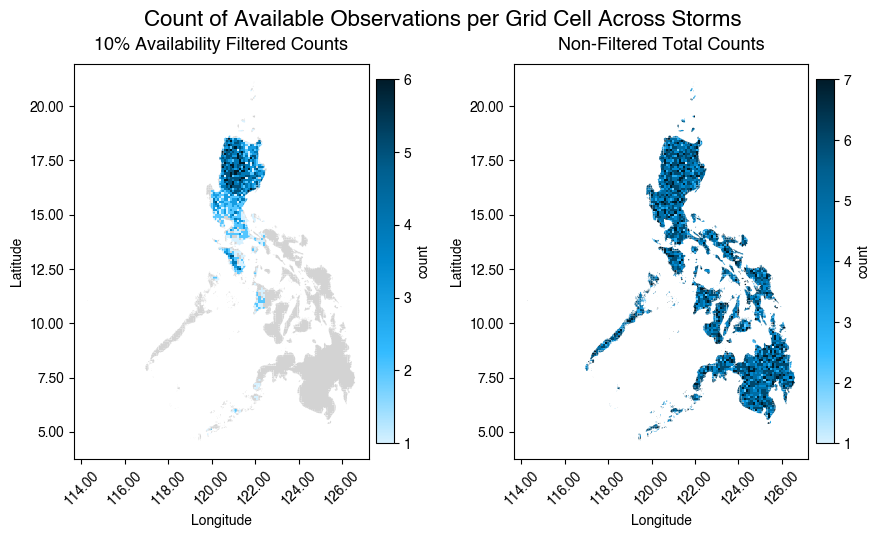

In [462]:
fig, axes = plot_choropleth_grid(
    [X_train_availability_cell_counts_gdf,X_train_total_cell_counts_gdf],
    columns=['count','count'],
    titles=["10% Availability Filtered Counts", 'Non-Filtered Total Counts'],
    cmaps=[same_scale_color_map, same_scale_color_map],
    suptitle="Count of Available Observations per Grid Cell Across Storms",
    missing_color='lightgrey',
    shared_scale=False,   # all panels use the same min/max
)
plt.show()

Okayyyy, now to look into ground cover of this to see if we can make any comparisons or see any relationships between the two.